#### Testing AutoGluon

In [11]:
import numpy as np
import pandas as pd
from autogluon.tabular import TabularPredictor
from sklearn.preprocessing import StandardScaler
from plots import plot_metrics

In [19]:
data = np.load("data/dataset_splits.npz")

data_proccesed = np.load("data/predictions/snv_sg1_preprocessed_spectra.npz")

X_train_processed = data_proccesed["X_train_pp"]
X_test_processed = data_proccesed["X_test_pp"]

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [14]:
scaler_X = StandardScaler()
X_s = scaler_X.fit_transform(X_train)

In [15]:
train_data_raw = pd.DataFrame(X_s, columns=[f"{i}" for i in range(X_train.shape[1])])
train_data_raw["label"] = y_train

In [16]:
predictor = TabularPredictor(label='label', eval_metric='r2', problem_type='regression').fit(train_data_raw)

No path specified. Models will be saved in: "AutogluonModels/ag-20260301_094819"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.10.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #101~22.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Feb 11 13:19:54 UTC 
CPU Count:          16
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 5.67/5.67 GB
Total GPU Memory:   Free: 5.67 GB, Allocated: 0.00 GB, Total: 5.67 GB
GPU Count:          1
Memory Avail:       20.70 GB / 31.05 GB (66.7%)
Disk Space Avail:   132.75 GB / 719.86 GB (18.4%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabu

In [17]:
y_pred_raw = predictor.predict(pd.DataFrame(scaler_X.transform(X_test), columns=[f"{i}" for i in range(X_test.shape[1])]))

In [20]:
predictor.leaderboard(extra_info=True, silent=False)
%clear

                 model  score_val eval_metric  pred_time_val   fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order  num_features  num_models  num_models_w_ancestors  memory_size  memory_size_w_ancestors  memory_size_min  memory_size_min_w_ancestors  num_ancestors  num_descendants                  model_type             child_model_type stopping_metric                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      hyperparameters                    hyperparameters_fit  \
0   

In [7]:
predictor_processed = TabularPredictor(label='label', eval_metric='r2', problem_type='regression').fit(pd.DataFrame(X_train_processed, columns=[f"{i}" for i in range(X_train_processed.shape[1])]).assign(label=y_train))

No path specified. Models will be saved in: "AutogluonModels/ag-20260301_094157"
/home/al/envs/torch/lib/python3.10/site-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.10.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #101~22.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Feb 11 13:19:54 UTC 
CPU Count:          16
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 5.67/5.67 GB
Total GPU Memory:   Free: 5.67 GB, Allocated: 0.00 GB, Total: 5.67 GB
GPU Count:          1
Memory Avail:       21.54 GB / 31.05 GB (69.4%)
Disk Space Avail:   132.84 GB / 719.86 GB (18.5%)
No presets specified! To achieve s

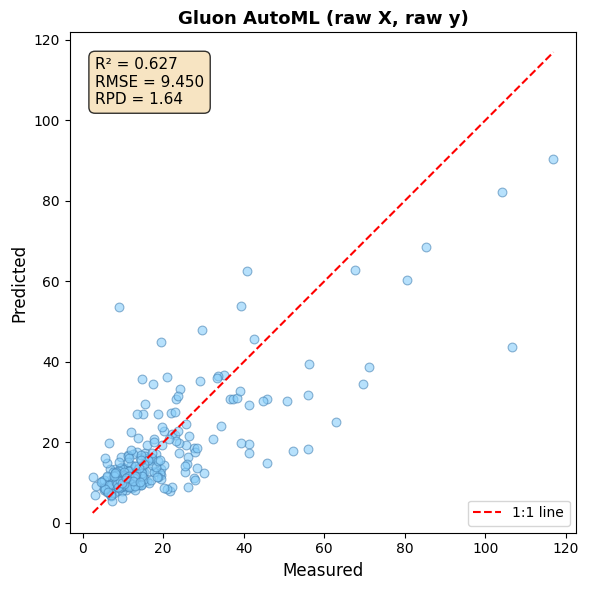

In [18]:
plot_metrics(
    y_test,
    y_pred_raw,
    "Gluon AutoML (raw X, raw y)",
)

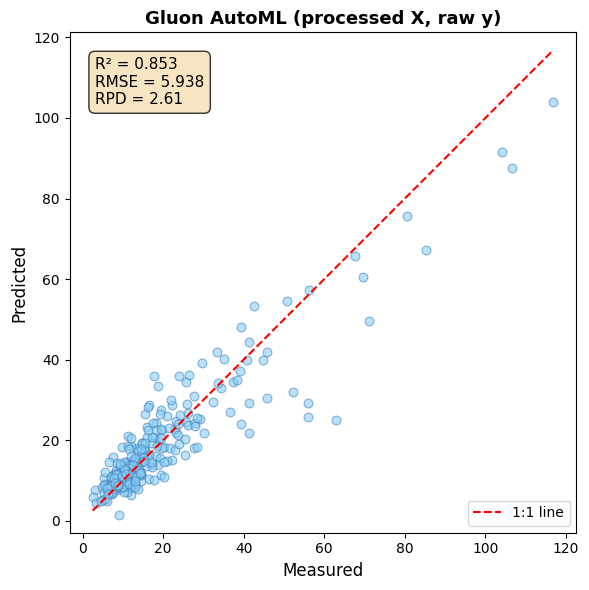

In [12]:
plot_metrics(
    y_test,
    predictor_processed.predict(pd.DataFrame(X_test_processed, columns=[f"{i}" for i in range(X_test_processed.shape[1])])),
    "Gluon AutoML (processed X, raw y)",
)

In [26]:
np.savez_compressed(
    "data/predictions/gluon_snv_sg1_preds.npz",
    pred_train=predictor_processed.predict(pd.DataFrame(X_train_processed, columns=[f"{i}" for i in range(X_train_processed.shape[1])])),
    pred_test=predictor_processed.predict(pd.DataFrame(X_test_processed, columns=[f"{i}" for i in range(X_test_processed.shape[1])]))
)

In [21]:
predictor_processed_log = TabularPredictor(label='label', eval_metric='r2', problem_type='regression').fit(pd.DataFrame(X_train_processed, columns=[f"{i}" for i in range(X_train_processed.shape[1])]).assign(label=y_train_log))

No path specified. Models will be saved in: "AutogluonModels/ag-20260301_095650"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.10.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #101~22.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Feb 11 13:19:54 UTC 
CPU Count:          16
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 5.67/5.67 GB
Total GPU Memory:   Free: 5.67 GB, Allocated: 0.00 GB, Total: 5.67 GB
GPU Count:          1
Memory Avail:       19.32 GB / 31.05 GB (62.2%)
Disk Space Avail:   132.60 GB / 719.86 GB (18.4%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabu

[1000]	valid_set's l2: 0.176843	valid_set's r2: 0.517342
[2000]	valid_set's l2: 0.176454	valid_set's r2: 0.518405
[3000]	valid_set's l2: 0.176435	valid_set's r2: 0.518458
[4000]	valid_set's l2: 0.176433	valid_set's r2: 0.518462
[5000]	valid_set's l2: 0.176433	valid_set's r2: 0.518463
[6000]	valid_set's l2: 0.176433	valid_set's r2: 0.518463
[7000]	valid_set's l2: 0.176433	valid_set's r2: 0.518463
[8000]	valid_set's l2: 0.176433	valid_set's r2: 0.518463
[9000]	valid_set's l2: 0.176433	valid_set's r2: 0.518463
[10000]	valid_set's l2: 0.176433	valid_set's r2: 0.518463


	0.5185	 = Validation score   (r2)
	67.29s	 = Training   runtime
	0.07s	 = Validation runtime
Fitting model: LightGBM ...
	Fitting with cpus=10, gpus=0, mem=0.2/18.3 GB


[1000]	valid_set's l2: 0.180828	valid_set's r2: 0.506467
[2000]	valid_set's l2: 0.180682	valid_set's r2: 0.506865
[3000]	valid_set's l2: 0.180679	valid_set's r2: 0.506873


	0.5069	 = Validation score   (r2)
	52.3s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestMSE ...
	Fitting with cpus=16, gpus=0
	0.4316	 = Validation score   (r2)
	26.54s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
	Fitting with cpus=10, gpus=0, mem=1.3/19.1 GB
	0.5712	 = Validation score   (r2)
	479.84s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: ExtraTreesMSE ...
	Fitting with cpus=16, gpus=0
	0.4338	 = Validation score   (r2)
	4.47s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: NeuralNetFastAI ...
	Fitting with cpus=10, gpus=0, mem=0.1/18.4 GB
	0.7204	 = Validation score   (r2)
	1.31s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: XGBoost ...
	Fitting with cpus=10, gpus=0
	0.4803	 = Validation score   (r2)
	14.45s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: NeuralNetTorch ...
	Fitting with cpus=10, gpus=0, mem=0.0/18.4 GB
/home/al/envs/t

[1000]	valid_set's l2: 0.215962	valid_set's r2: 0.410577
[2000]	valid_set's l2: 0.215962	valid_set's r2: 0.410578
[3000]	valid_set's l2: 0.215962	valid_set's r2: 0.410578
[4000]	valid_set's l2: 0.215962	valid_set's r2: 0.410578
[5000]	valid_set's l2: 0.215962	valid_set's r2: 0.410578
[6000]	valid_set's l2: 0.215962	valid_set's r2: 0.410578
[7000]	valid_set's l2: 0.215962	valid_set's r2: 0.410578


	0.4106	 = Validation score   (r2)
	429.42s	 = Training   runtime
	0.09s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ...
	Fitting 1 model on all data | Fitting with cpus=16, gpus=0, mem=0.0/18.1 GB
	Ensemble Weights: {'NeuralNetTorch': 0.571, 'NeuralNetFastAI': 0.429}
	0.7558	 = Validation score   (r2)
	0.04s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 1083.56s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 1918.0 rows/s (251 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/home/al/projects/reflectance_coding/last_task/AutogluonModels/ag-20260301_095650")


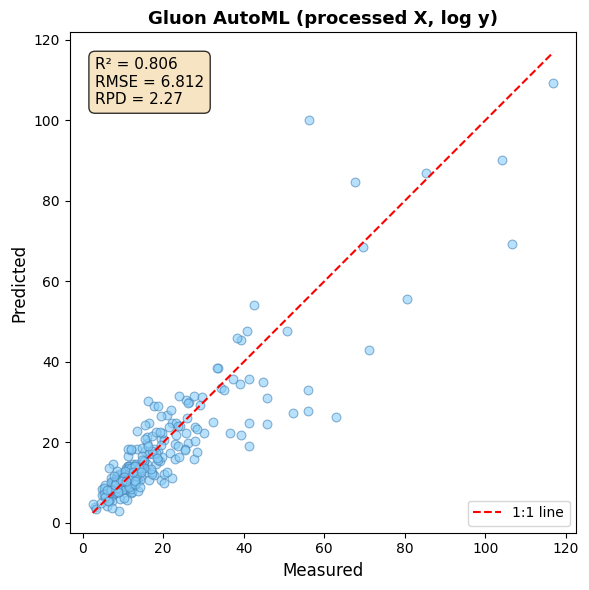

In [24]:
plot_metrics(
    y_test,
    np.expm1(predictor_processed_log.predict(pd.DataFrame(X_test_processed, columns=[f"{i}" for i in range(X_test_processed.shape[1])]))),
    "Gluon AutoML (processed X, log y)",
)

In [25]:
np.savez_compressed(
    "data/predictions/gluon_snv_sg1_y_log_preds.npz",
    pred_train=np.expm1(predictor_processed_log.predict(pd.DataFrame(X_train_processed, columns=[f"{i}" for i in range(X_train_processed.shape[1])]))),
    pred_test=np.expm1(predictor_processed_log.predict(pd.DataFrame(X_test_processed, columns=[f"{i}" for i in range(X_test_processed.shape[1])])))
)